In [10]:
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/home/dongyoonhwang/.mujoco/mujoco210/bin:/usr/lib/nvidia
!export MUJOCO_PY_MJKEY_PATH=/home/nas2_userI/byungkunlee/.mujoco/mjkey.txt
!export MJKEY_PATH=/home/nas2_userI/byungkunlee/.mujoco/mjkey.txt
!export MJLIB_PATH=/home/nas2_userI/byungkunlee/.mujoco/mujoco210/bin/libmujoco210.so
!export MUJOCO_PY_MUJOCO_PATH=/home/dongyoonhwang/.mujoco/mujoco210

# >>> MuJoCo visualization >>>
!export XLA_PYTHON_CLIENT_PREALLOCATE=false
!export MUJOCO_GL='egl'
!export MUJOCO_EGL_DEVICE_ID='0'
!export MKL_SERVICE_FORCE_INTEL='0'

In [3]:
import sys
import os
sys.path.append("../")
sys.path.append("../..")

In [4]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from scale_rl.common.wandb_utils import *

In [6]:
from color import METHOD_COLORS, METHOD_BOUNDARY_COLORS, BORDER_GRAY

In [7]:
simbav2_rr1_eval_df = pd.read_csv('../../results/simbaV2_utd1.csv', index_col=0)
simbav2_rr2_eval_df = pd.read_csv('../../results/simbaV2_utd2.csv', index_col=0)
simbav2_rr4_eval_df = pd.read_csv('../../results/simbaV2_utd4.csv', index_col=0)
simbav2_rr8_eval_df = pd.read_csv('../../results/simbaV2_utd8.csv', index_col=0)

simbav2_rr1_eval_df["exp_name"] = "UTD = 1"
simbav2_rr2_eval_df["exp_name"] = "UTD = 2"
simbav2_rr4_eval_df["exp_name"] = "UTD = 4"
simbav2_rr8_eval_df["exp_name"] = "UTD = 8"

#### Collection

In [8]:
eval_df = pd.concat([
    simbav2_rr1_eval_df,
    simbav2_rr2_eval_df,
    simbav2_rr4_eval_df,
    simbav2_rr8_eval_df,
    ], ignore_index=True, sort=False)
eval_df['env_name'] = eval_df['env_name'].str.replace('_', '-')
eval_df

,exp_name,env_name,seed,metric,env_step,value
0,UTD = 1,Hopper-v4,4000,avg_return,0.0,13.854812
1,UTD = 1,Hopper-v4,4000,avg_return,50000.0,406.395977
2,UTD = 1,Hopper-v4,4000,avg_return,100000.0,697.883268
3,UTD = 1,Hopper-v4,4000,avg_return,150000.0,1536.789357
4,UTD = 1,Hopper-v4,4000,avg_return,200000.0,3178.249772
...,...,...,...,...,...,...
38954,UTD = 8,h1-stand-v0,0,avg_success,600000.0,0.000000
38955,UTD = 8,h1-stand-v0,0,avg_success,700000.0,0.000000
38956,UTD = 8,h1-stand-v0,0,avg_success,800000.0,0.000000
38957,UTD = 8,h1-stand-v0,0,avg_success,900000.0,0.000000


In [11]:
from scale_rl.envs.mujoco import MUJOCO_ALL, MUJOCO_RANDOM_SCORE, MUJOCO_TD3_SCORE
from scale_rl.envs.dmc import DMC_EASY_MEDIUM, DMC_HARD
from scale_rl.envs.humanoid_bench import HB_LOCOMOTION_NOHAND, HB_RANDOM_SCORE, HB_SUCCESS_SCORE
from scale_rl.envs.myosuite import MYOSUITE_TASKS

def replace_hypen_to_underbar(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('_', '-')
    return env_name_list
def replace_hypen_to_underbar_dict(env_name_dict):
    _new_dict = {}
    for k, v in env_name_dict.items():
        _new_dict[k.replace('_', '-')] = v
    return _new_dict

MUJOCO_ALL = replace_hypen_to_underbar(MUJOCO_ALL)
DMC_EASY_MEDIUM = replace_hypen_to_underbar(DMC_EASY_MEDIUM)
DMC_HARD = replace_hypen_to_underbar(DMC_HARD)
HB_LOCOMOTION_NOHAND = replace_hypen_to_underbar(HB_LOCOMOTION_NOHAND)
MYOSUITE_TASKS = replace_hypen_to_underbar(MYOSUITE_TASKS)

HB_SUCCESS_SCORE = replace_hypen_to_underbar_dict(HB_SUCCESS_SCORE)
HB_RANDOM_SCORE = replace_hypen_to_underbar_dict(HB_RANDOM_SCORE)

DMC_ALL = [*DMC_EASY_MEDIUM, *DMC_HARD]

In [40]:
base_color = METHOD_BOUNDARY_COLORS["SimbaV2"]

rr1_color = "#ccdcfe"
rr2_color = "#9abafd"
rr4_color = "#4f86fc"
rr8_color = "#034ae1"

colors = {
    'UTD = 1': rr1_color,
    'UTD = 2': rr2_color,
    'UTD = 4': rr4_color,
    'UTD = 8': rr8_color,
}

In [41]:
simbav2_marker = 'o'
markers = {
    'UTD = 1': 'o',
    'UTD = 2': 'o',
    'UTD = 4': 'o',
    'UTD = 8': 'o',
}
markeverys = {
    'UTD = 1': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 2, "DMC Hard": 2, "MyoSuite": 2, "HumanoidBench": 2},
    'UTD = 2': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 2, "DMC Hard": 2, "MyoSuite": 2, "HumanoidBench": 2},
    'UTD = 4': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 2, "DMC Hard": 2, "MyoSuite": 2, "HumanoidBench": 2},
    'UTD = 8': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 2, "DMC Hard": 2, "MyoSuite": 2, "HumanoidBench": 2},
}

In [42]:
# For plot
marker_sizes_all = {
    'UTD = 1': 125,
    'UTD = 2': 125,
    'UTD = 4': 125,
    'UTD = 8': 125,
}
marker_sizes = {
    'UTD = 1': 125,
    'UTD = 2': 125,
    'UTD = 4': 125,
    'UTD = 8': 125,
}

In [43]:
FONT_SIZE = 18

### Visualization

In [44]:
MUJ_STEPS = 1000000 # 1M
DMC_STEPS = 1000000 # 1M
MYO_STEPS = 1000000 # 1M
HB_STEPS = 1000000 # 1M

In [45]:
def normalize_score_with_random_and_base_score(
    df: pd.DataFrame, random_score_dict: dict, base_score_dict: dict
) -> pd.DataFrame:
    """
    Normalize the 'value' column based on random and base scores.
        normalized_value = (value - random_score) / (base_score - random_score)

    Args:
    - df (pd.DataFrame): DataFrame with 'env_name' and 'value' columns.
    - random_score_dict (dict): Mapping of 'env_name' to random scores.
    - base_score_dict (dict): Mapping of 'env_name' to base scores.

    Returns:
    - pd.DataFrame: DataFrame with an added 'normalized_value' column.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_normalized = df.copy()

    # Define a function to normalize a single value
    def normalize_value(row):
        env_name = row["env_name"]
        value = row["value"]
        base_score = base_score_dict[env_name]
        random_score = random_score_dict[env_name]

        return (value - random_score) / (base_score - random_score)

    # Apply the normalization function to each row
    df_normalized["value"] = df_normalized.apply(normalize_value, axis=1)

    return df_normalized

In [46]:
def set_identical_grid(ax, x_num_ticks, y_num_ticks, tick_x_min, tick_x_max, tick_y_min, tick_y_max):
    # This function adds evenly spaced grid lines
    ax.xaxis.set_major_locator(plt.MaxNLocator(x_num_ticks, integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(y_num_ticks, integer=True))
    ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    # Set ticks after limits are defined
    ax.set_xticks(np.linspace(tick_x_min, tick_x_max, x_num_ticks))
    ax.set_yticks(np.linspace(tick_y_min, tick_y_max, y_num_ticks))
    
def simple_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

### ALL

In [47]:
def plot_multiple_environment_metrics(
    env_dfs,
    env_names,
    colors,
    metrics,
    x_lim_mins,
    x_lim_maxs,
    y_lim_mins,
    y_lim_maxs,
    y_labels,
    custom_titles,
    bbox_to_anchor,
    plot_width: int = 24,
    plot_height: int = 5,
    x_num_ticks: int = 5,
    y_num_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5,
):
    num_envs = len(env_dfs)
    # Set up the figure
    # sns.set_style('darkgrid', {"axes.facecolor": "whitesmoke", "grid.color": "gray"})
    sns.set_style('whitegrid')    
    
    fig, axs = plt.subplots(1, num_envs, figsize=(plot_width, plot_height), squeeze=False)
    fig.subplots_adjust(wspace=0.5)
    axs = axs.flatten()  # Flatten in case of a single subplot

    all_experiments = set()

    for i, (env_df, env_name) in enumerate(zip(env_dfs, env_names)):
        ax = axs[i]
        metric = metrics[i]
        x_lim_min = x_lim_mins[i]
        x_lim_max = x_lim_maxs[i]
        y_lim_min = y_lim_mins[i]
        y_lim_max = int(np.ceil(y_lim_maxs[i]))  # Round up to nearest integer

        env_df = env_df[env_df["metric"] == metric]
        experiments = env_df["exp_name"].unique()
        
        # custom
        experiments = ['UTD = 1', 'UTD = 2', 'UTD = 4', 'UTD = 8']
        
        all_experiments.update(experiments)

        for exp in experiments:
            exp_data = env_df[env_df["exp_name"] == exp]
            if len(exp_data) == 0:
                continue
            num_seeds = exp_data["seed"].nunique()
            
            # Check if env_step = 0 exists, if not, add it with value 0
            if 0 not in exp_data["env_step"].values:
                zero_row = pd.DataFrame({
                    "env_step": [0],
                    "value": [0],
                    "exp_name": [exp],
                    "metric": [metric]
                })
                exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                
            # Group by env_step and calculate mean across all environments
            grouped_data = exp_data.groupby("env_step")["value"]
            
            env_steps = grouped_data.mean().index.values
            mean = grouped_data.mean().values
            std_error = grouped_data.sem().values  # Standard error of the mean

            # Multiply by 10 for MyoSuite
            if env_name == "MyoSuite":
                mean *= 100
                std_error *= 100
                y_lim_max = 100  # Set y_lim_max to 100 for percentage

            # Plot mean history with thicker lines
            from scipy.ndimage import convolve
            #mean = convolve(mean, [1/3,1/3,1/3])
            if exp == 'UTD = 8':
                zorder = 20
            else:
                zorder = 0
            ax.plot(env_steps, 
                    mean, 
                    label=exp, 
                    linewidth=line_width, 
                    color=colors[exp], 
                    marker=markers[exp], 
                    markevery=markeverys[exp][env_name],
                    zorder=zorder)
            
            # Fill between mean - std_error and mean + std_error
            ax.fill_between(
                env_steps,
                mean - 1.96*std_error,
                mean + 1.96*std_error,
                alpha=0.2,
                color=colors[exp],
            )

        # Set labels and limits
        ax.set_xlabel(x_label, fontsize=18)
        ax.set_autoscalex_on(False)
        ax.set_autoscaley_on(False)
        ax.set_xlim(x_lim_min, x_lim_max)
        ax.set_ylim(y_lim_min, y_lim_max)

        # Set x-ticks and format them
        x_ticks = np.linspace(x_lim_min, x_lim_max, x_num_ticks)
        ax.set_xticks(x_ticks)
        # Format x-tick labels
        x_tick_labels = []
        for tick in x_ticks:
            if tick == 0:
                x_tick_labels.append("0")
            else:
                x_tick_labels.append("{:.1f}".format(tick / 1e6))
        
        ax.set_xticklabels(x_tick_labels, fontsize=16)

        # Set y-ticks (only 3) and format them as integers
        y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
        ax.set_yticks(y_ticks)
        #ax.set_xscale('log')
        ax.set_yticklabels(["{:,d}".format(int(tick)) for tick in y_ticks], fontsize=16)

        # Add custom title with first line bold
        title = custom_titles[i]
        ax.set_title('')  # Clear any existing title
        ax.text(0.5, 1.03, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=18)
        set_identical_grid(
            ax, 
            x_num_ticks=x_num_ticks, 
            y_num_ticks=y_num_ticks,
            tick_x_min=x_lim_min,
            tick_x_max=x_lim_max,
            tick_y_min=y_lim_min,
            tick_y_max=y_lim_max,
        )
        simple_axis(ax)
    
    # Add shared legend below the subplots
    handles, labels = ax.get_legend_handles_labels()
    plt.subplots_adjust(bottom=0.15)

    # Add markers to the legend
    # handles = [legend_handles[k] for k in labels]
    leg = fig.legend(handles, labels, loc='lower center', ncol=len(all_experiments), bbox_to_anchor=bbox_to_anchor, fontsize='x-large',) # handletextpad=0.1,)
    leg.get_frame().set_linewidth(0.0)
    
    # Adjust layout and display
    plt.savefig("appendix_utd_all_learning_curve.png",bbox_inches='tight')

/tmp/ipykernel_2640479/1310339749.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dmc_easy_medium_eval_df["value"] = dmc_easy_medium_eval_df["value"] / 1000
/tmp/ipykernel_2640479/1310339749.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dmc_hard_eval_df["value"] = dmc_hard_eval_df["value"] / 1000


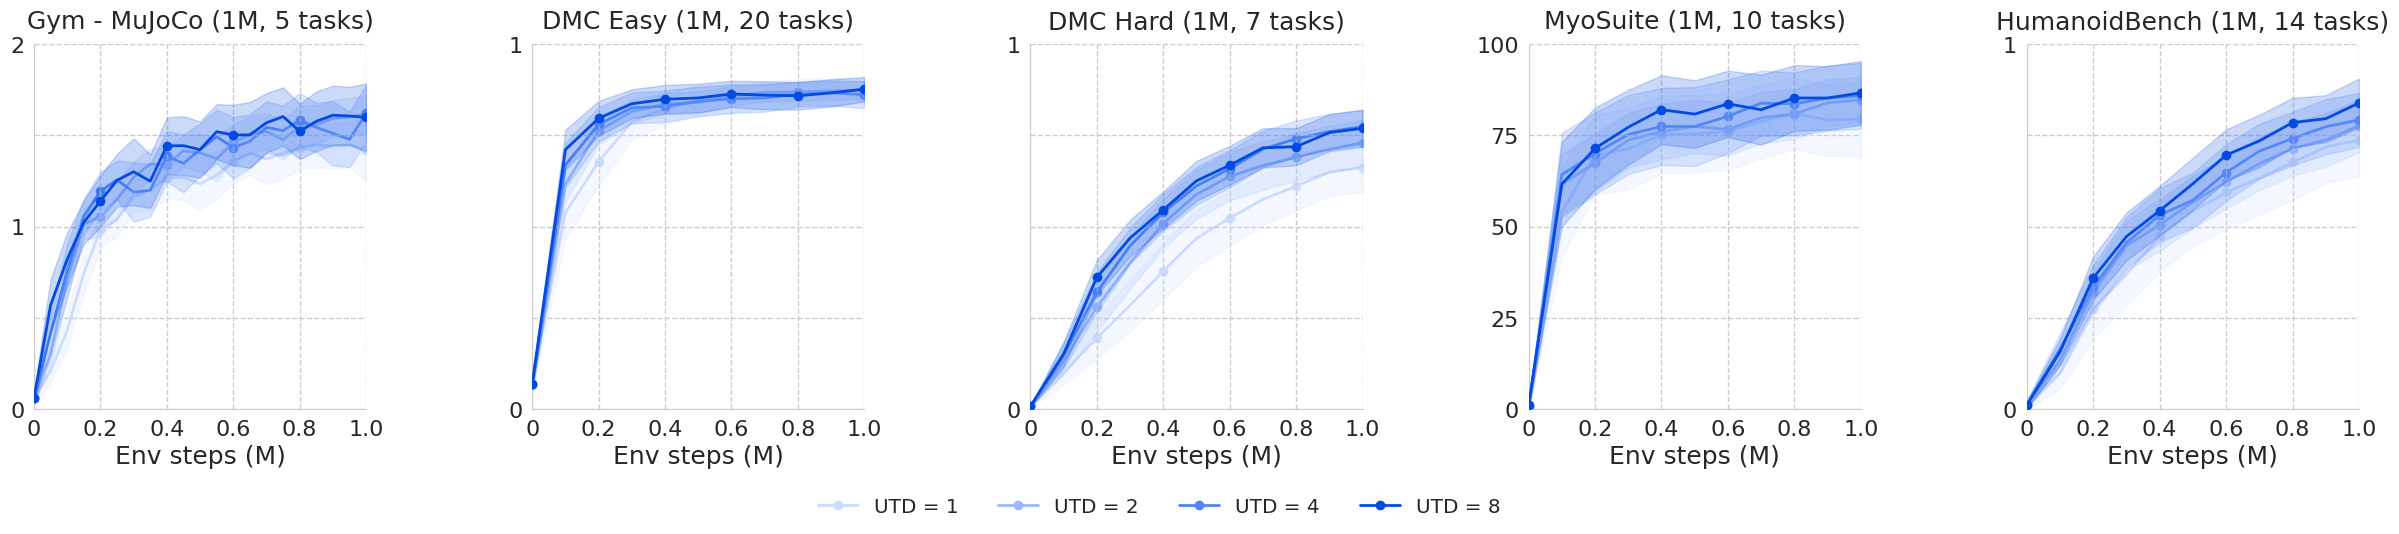

In [48]:
mujoco_eval_df = eval_df[eval_df['env_name'].isin(MUJOCO_ALL)]
mujoco_eval_df = normalize_score_with_random_and_base_score(
    df=mujoco_eval_df,
    random_score_dict=MUJOCO_RANDOM_SCORE,
    base_score_dict=MUJOCO_TD3_SCORE,
)
dmc_easy_medium_eval_df = eval_df[eval_df['env_name'].isin(DMC_EASY_MEDIUM)]
dmc_easy_medium_eval_df["value"] = dmc_easy_medium_eval_df["value"] / 1000

dmc_hard_eval_df = eval_df[eval_df['env_name'].isin(DMC_HARD)]
dmc_hard_eval_df["value"] = dmc_hard_eval_df["value"] / 1000

myo_eval_df = eval_df[eval_df['env_name'].isin(MYOSUITE_TASKS)]
hb_eval_df = eval_df[eval_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]
hb_eval_df = normalize_score_with_random_and_base_score(
    df=hb_eval_df,
    random_score_dict=HB_RANDOM_SCORE,
    base_score_dict=HB_SUCCESS_SCORE,
)

plot_multiple_environment_metrics(
    env_dfs=[mujoco_eval_df, dmc_easy_medium_eval_df, dmc_hard_eval_df, myo_eval_df, hb_eval_df],
    env_names=["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard", "MyoSuite", "HumanoidBench"],
    metrics=["avg_return", "avg_return", "avg_return", "avg_success", "avg_return"],
    colors=colors,
    x_lim_mins=[0, 0, 0, 0, 0],
    x_lim_maxs=[1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6],
    y_lim_mins=[0, 0, 0, 0, 0],
    y_lim_maxs=[2.0, 1.0, 1.0, 100, 1.0],
    y_labels=["Average Return", "Success Rate (%)"],
    custom_titles=[
        "Gym - MuJoCo (1M, 5 tasks)",
        "DMC Easy (1M, 20 tasks)",
        "DMC Hard (1M, 7 tasks)",
        "MyoSuite (1M, 10 tasks)",
        "HumanoidBench (1M, 14 tasks)",
    ],
    x_num_ticks=6,
    line_width=2.0,
    plot_width= 30,
    plot_height= 5,
    bbox_to_anchor=(0.5, -0.1)
)

### Per environments

In [49]:
TITLE_FONTSIZE = 14
X_FONTSIZE = 14
Y_FONTSIZE = 14

In [50]:
def plot_environment_metrics_per_env(
    env_dfs,
    env_names,
    env_dicts,
    colors,
    metrics,
    x_lim_mins,
    x_lim_maxs,
    y_lim_mins,
    y_lim_maxs,
    y_labels,
    plot_widths: list,
    plot_heights: list,
    plot_hspaces: list,
    plot_wspaces: list,
    legend_bbox_to_anchors: list,
    num_plots_per_row=4,
    x_num_ticks: int = 6,
    y_num_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5
):
    for i, env_dict in enumerate(env_dicts):
        # indexing
        metric = metrics[i]
        x_lim_min, x_lim_max = x_lim_mins[i], x_lim_maxs[i]
        if i > 0 and i < len(env_dicts) - 1:
            y_lim_min, y_lim_max = y_lim_mins[i], int(np.ceil(y_lim_maxs[i]))  # Round up to nearest integer
        elif i == len(env_dicts) - 1:
            hb_y_info = y_lim_maxs[-1]
        else:
            mujoco_y_info = y_lim_mins[0]
        y_label = y_labels[i]
        plot_width, plot_height = plot_widths[i], plot_heights[i]
        wspace, hspace = plot_wspaces[i], plot_hspaces[i]
        bbox_to_anchor = legend_bbox_to_anchors[i]
        env_df, env_name = env_dfs[i], env_names[i]
            
        num_plots = len(env_dict)
        ncols = min(num_plots_per_row, num_plots)
        nrows = (num_plots + ncols - 1) // ncols  # Calculate number of rows needed
        num_removes = ncols * nrows - num_plots 
        
        # Set up the figure
        # sns.set_style('darkgrid', {"axes.facecolor": "white", "grid.color": BORDER_GRAY})
        sns.set_style('whitegrid')    
        
        fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(plot_width, plot_height), squeeze=False)
        fig.subplots_adjust(hspace=hspace, wspace=wspace)
        axs = axs.flatten()  # Flatten in case of a single subplot
        
        for _elim_idx in range(1, num_removes+1):
            axs.flat[-1 * _elim_idx].set_visible(False) # # Remove empty subplots

        all_experiments = set()

        for j, env in enumerate(env_dict):
            ax = axs[j] # plot for env_name
            
            env_data = env_df[env_df["env_name"] == env]
            env_data = env_data[env_data["metric"] == metric]
            experiments = env_data["exp_name"].unique()
            
            # custom
            experiments = ['UTD = 1', 'UTD = 2', 'UTD = 4', 'UTD = 8']
            
            all_experiments.update(experiments)

            for exp in experiments:
                exp_data = env_data[env_data["exp_name"] == exp]
                exp_data = exp_data[exp_data["env_step"] <= x_lim_max]
                if len(exp_data) == 0:
                    continue
                
                num_seeds = exp_data["seed"].nunique()
                
                # Check if env_step = 0 exists, if not, add it with value 0
                if 0 not in exp_data["env_step"].values:
                    zero_row = pd.DataFrame({
                        "env_step": [0],
                        "value": [0],
                        "exp_name": [exp],
                        "metric": [metric]
                    })
                    exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                    
                # Group by env_step and calculate mean across all environments
                grouped_data = exp_data.groupby(["env_step"])["value"]
                env_steps = grouped_data.mean().index.values
                mean = grouped_data.mean().values
                std_error = grouped_data.sem().values  # Standard error of the mean

                # Multiply by 10 for MyoSuite
                if env_name == "MyoSuite":
                    mean *= 100
                    std_error *= 100
                    y_lim_max = 100  # Set y_lim_max to 100 for percentage

                # Plot mean history with thicker lines
                from scipy.ndimage import convolve
                # mean = convolve(mean, [1/3,1/3,1/3])
                if exp == 'UTD = 8':
                    zorder = 30
                elif exp == 'UTD = 4':
                    zorder = 20
                elif exp == 'UTD = 2':
                    zorder = 10
                elif exp == 'UTD = 1':
                    zorder = 0
                else:
                    zorder = -10
                ax.plot(env_steps, 
                        mean, 
                        label=exp, 
                        linewidth=line_width, 
                        color=colors[exp], 
                        marker=markers[exp], 
                        markevery=markeverys[exp][env_name],
                        zorder=zorder)
                
                
                # Draw markers
                # timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
                # markers_idx = list(range(0, len(mean), len(mean) // (x_num_ticks-1)))
                # timestep_list = [t for t in timestep_list if t <= max(env_steps)]
                # markers_idx = markers_idx[:len(timestep_list)]
                # markers_values = np.interp(timestep_list, env_steps, mean)
                # ax.scatter(timestep_list,
                #            markers_values,
                #            label=None,
                #            color=colors[exp], 
                #            edgecolor='white',
                #            marker=markers[exp], 
                #            s=marker_sizes[exp],
                #            zorder=zorder+5)

                # Fill between mean - std_error and mean + std_error
                ax.fill_between(
                    env_steps,
                    mean - 1.96*std_error,
                    mean + 1.96*std_error,
                    alpha=0.2,
                    color=colors[exp],
                )
            
            # Set labels and limits
            ax.set_xlabel(x_label, fontsize=X_FONTSIZE)
            if j % num_plots_per_row == 0: 
                ax.set_ylabel(y_label, fontsize=Y_FONTSIZE) # set ylabels for only leftmost subplots
            
            x_len = x_lim_max - x_lim_min
            ax.set_xlim(x_lim_min - 0.1*x_len, x_lim_max + 0.1*x_len)
            if env_name == "Gym - MuJoCo":
                y_lim_min, y_lim_max = mujoco_y_info[env]["y_lim_min"], mujoco_y_info[env]["y_lim_max"]
                y_len = y_lim_max - y_lim_min
                ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            elif env_name == "HumanoidBench":
                y_lim_max = hb_y_info[env]['y_lim_max']
                y_lim_min = 0
                y_len = y_lim_max
                ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
                
                if HB_SUCCESS_SCORE[env] <= y_lim_max:
                    ax.axhline(y=HB_SUCCESS_SCORE[env], color='black', linestyle='--') 
                    
                    ax.text(0.025, HB_SUCCESS_SCORE[env] - hb_y_info[env].get("y_success_offset", 100), "Success", transform=ax.get_yaxis_transform(), color='black') #, transform=ax.get_yaxis_transform())
            else:
                y_len = y_lim_max - y_lim_min
                ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)

            # Set x-ticks and format them
            x_ticks = np.linspace(x_lim_min, x_lim_max, x_num_ticks)
            ax.set_xticks(x_ticks)
            # Format x-tick labels
            x_tick_labels = []
            for tick in x_ticks:
                if tick == 0:
                    x_tick_labels.append("0")
                else:
                    x_tick_labels.append("{:.1f}".format(tick / 1e6))
            
            ax.set_xticklabels(x_tick_labels, fontsize=12)

            if env_name == "Gym - MuJoCo":
                # Set y-ticks (only 3) and format them as integers
                y_num_ticks = mujoco_y_info[env]["y_num_ticks"]
                y_lim_min, y_lim_max = mujoco_y_info[env]["y_lim_min"], mujoco_y_info[env]["y_lim_max"]
                y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
                ax.set_yticks(y_ticks)
                #ax.set_xscale('log')
                ax.set_yticklabels(["{:,d}K".format(int(tick / 1000)) for tick in y_ticks], fontsize=12)
            elif env_name == "HumanoidBench":
                # Set y-ticks (only 3) and format them as integers
                y_num_ticks = hb_y_info[env].get("y_num_ticks", 5)
                y_lim_min, y_lim_max = 0, hb_y_info[env]["y_lim_max"]
                y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
                ax.set_yticks(y_ticks)
            else:
                # Set y-ticks (only 3) and format them as integers
                y_num_ticks = 5
                y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
                ax.set_yticks(y_ticks)
                #ax.set_xscale('log')
                ax.set_yticklabels(["{:,d}".format(int(tick)) for tick in y_ticks], fontsize=12)
            
            set_identical_grid(
                ax, 
                x_num_ticks=x_num_ticks, 
                y_num_ticks=y_num_ticks,
                tick_x_min=x_lim_min,
                tick_x_max=x_lim_max,
                tick_y_min=y_lim_min,
                tick_y_max=y_lim_max,
            )
            simple_axis(ax)
            
            # Add custom title with first line bold
            title = env
            ax.set_title('')  # Clear any existing title
            ax.text(0.5, 1.08, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=TITLE_FONTSIZE)
            
            ax.use_sticky_edges = False
            ax.set_xmargin(5.25)
            ax.set_ymargin(2.5)        

        # Add shared legend below the subplots
        handles, labels = ax.get_legend_handles_labels()
        plt.subplots_adjust(bottom=0.15)

        # Add markers to the legend
        # handles = [legend_handles[k] for k in labels]
        leg = fig.legend(handles, labels, loc='lower center', ncol=len(all_experiments), bbox_to_anchor=bbox_to_anchor, fontsize='x-large',) # handletextpad=0.1,)
        leg.get_frame().set_linewidth(0.0)

        # Adjust layout and display
        save = {
            "Gym - MuJoCo": "gym",
            "DMC Easy-Medium": "dmc_em",
            "DMC Hard": "dmc_hard",
            "MyoSuite": "myo",
            "HumanoidBench": "hb",
        }
        plt.savefig(f"appendix_utd_{save[env_name]}_learning_curve.png",bbox_inches='tight')
        plt.savefig(f"appendix_utd_{save[env_name]}_learning_curve.pdf",bbox_inches='tight')

In [51]:
mujoco_y_info = {
    "Ant-v4": {
        "y_lim_min": -2000,
        "y_lim_max": 10000,
        "y_num_ticks": 4,
    },
    "HalfCheetah-v4": {
        "y_lim_min": -2000,
        "y_lim_max": 18000, 
        "y_num_ticks": 5,
    },
    "Hopper-v4": {
        "y_lim_min": -1000,
        "y_lim_max": 4000, 
        "y_num_ticks": 5,
    },
    "Humanoid-v4": {
        "y_lim_min": -2000,
        "y_lim_max": 12000, 
        "y_num_ticks": 5,
    },
    "Walker2d-v4": {
        "y_lim_min": -1000,
        "y_lim_max": 8000, 
        "y_num_ticks": 5,
    }
}

In [52]:
hb_y_lim_max_info = {
    "h1-walk-v0": {
        "y_lim_max": 1000,
    },
    "h1-stand-v0": {
        "y_lim_max": 1000,
    },
    "h1-run-v0": {
        "y_lim_max": 1000,
    },
    "h1-reach-v0": {
        "y_lim_max": 15000,
        "y_num_ticks": 7,
        "y_success_offset": 1500,
    },
    "h1-hurdle-v0": {
        "y_lim_max": 1000,
    },
    "h1-crawl-v0": {
        "y_lim_max": 1000,
    },
    "h1-maze-v0": {
        "y_lim_max": 1500,
        "y_num_ticks": 7,
        "y_success_offset": 150,
    },
    "h1-sit-simple-v0": {
        "y_lim_max": 1000,
    },
    "h1-sit-hard-v0": {
        "y_lim_max": 1000,
    },
    "h1-balance-simple-v0": {
        "y_lim_max": 1000,
    },
    "h1-balance-hard-v0": {
        "y_lim_max": 1000,
    },
    "h1-stair-v0": {
        "y_lim_max": 1000,
    },
    "h1-slide-v0": {
        "y_lim_max": 1000,
    },
    "h1-pole-v0": {
        "y_lim_max": 1000,
    },
}

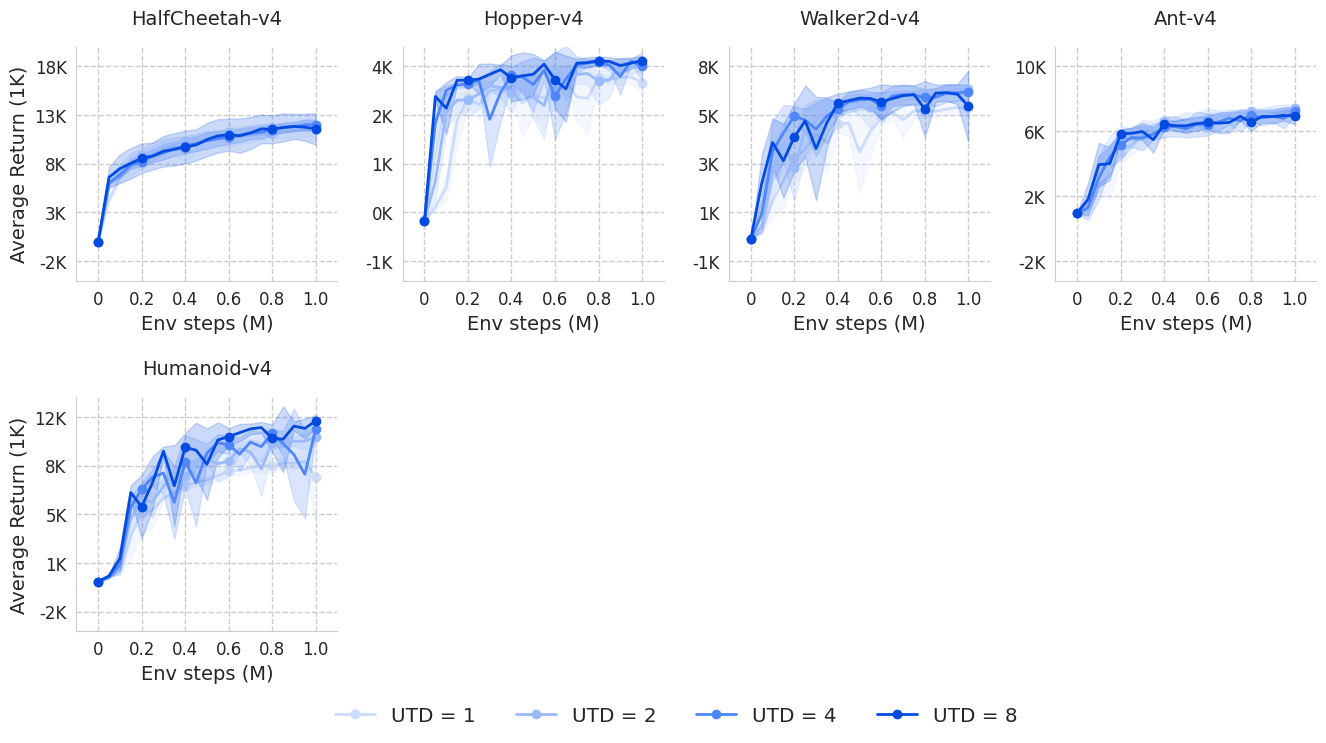

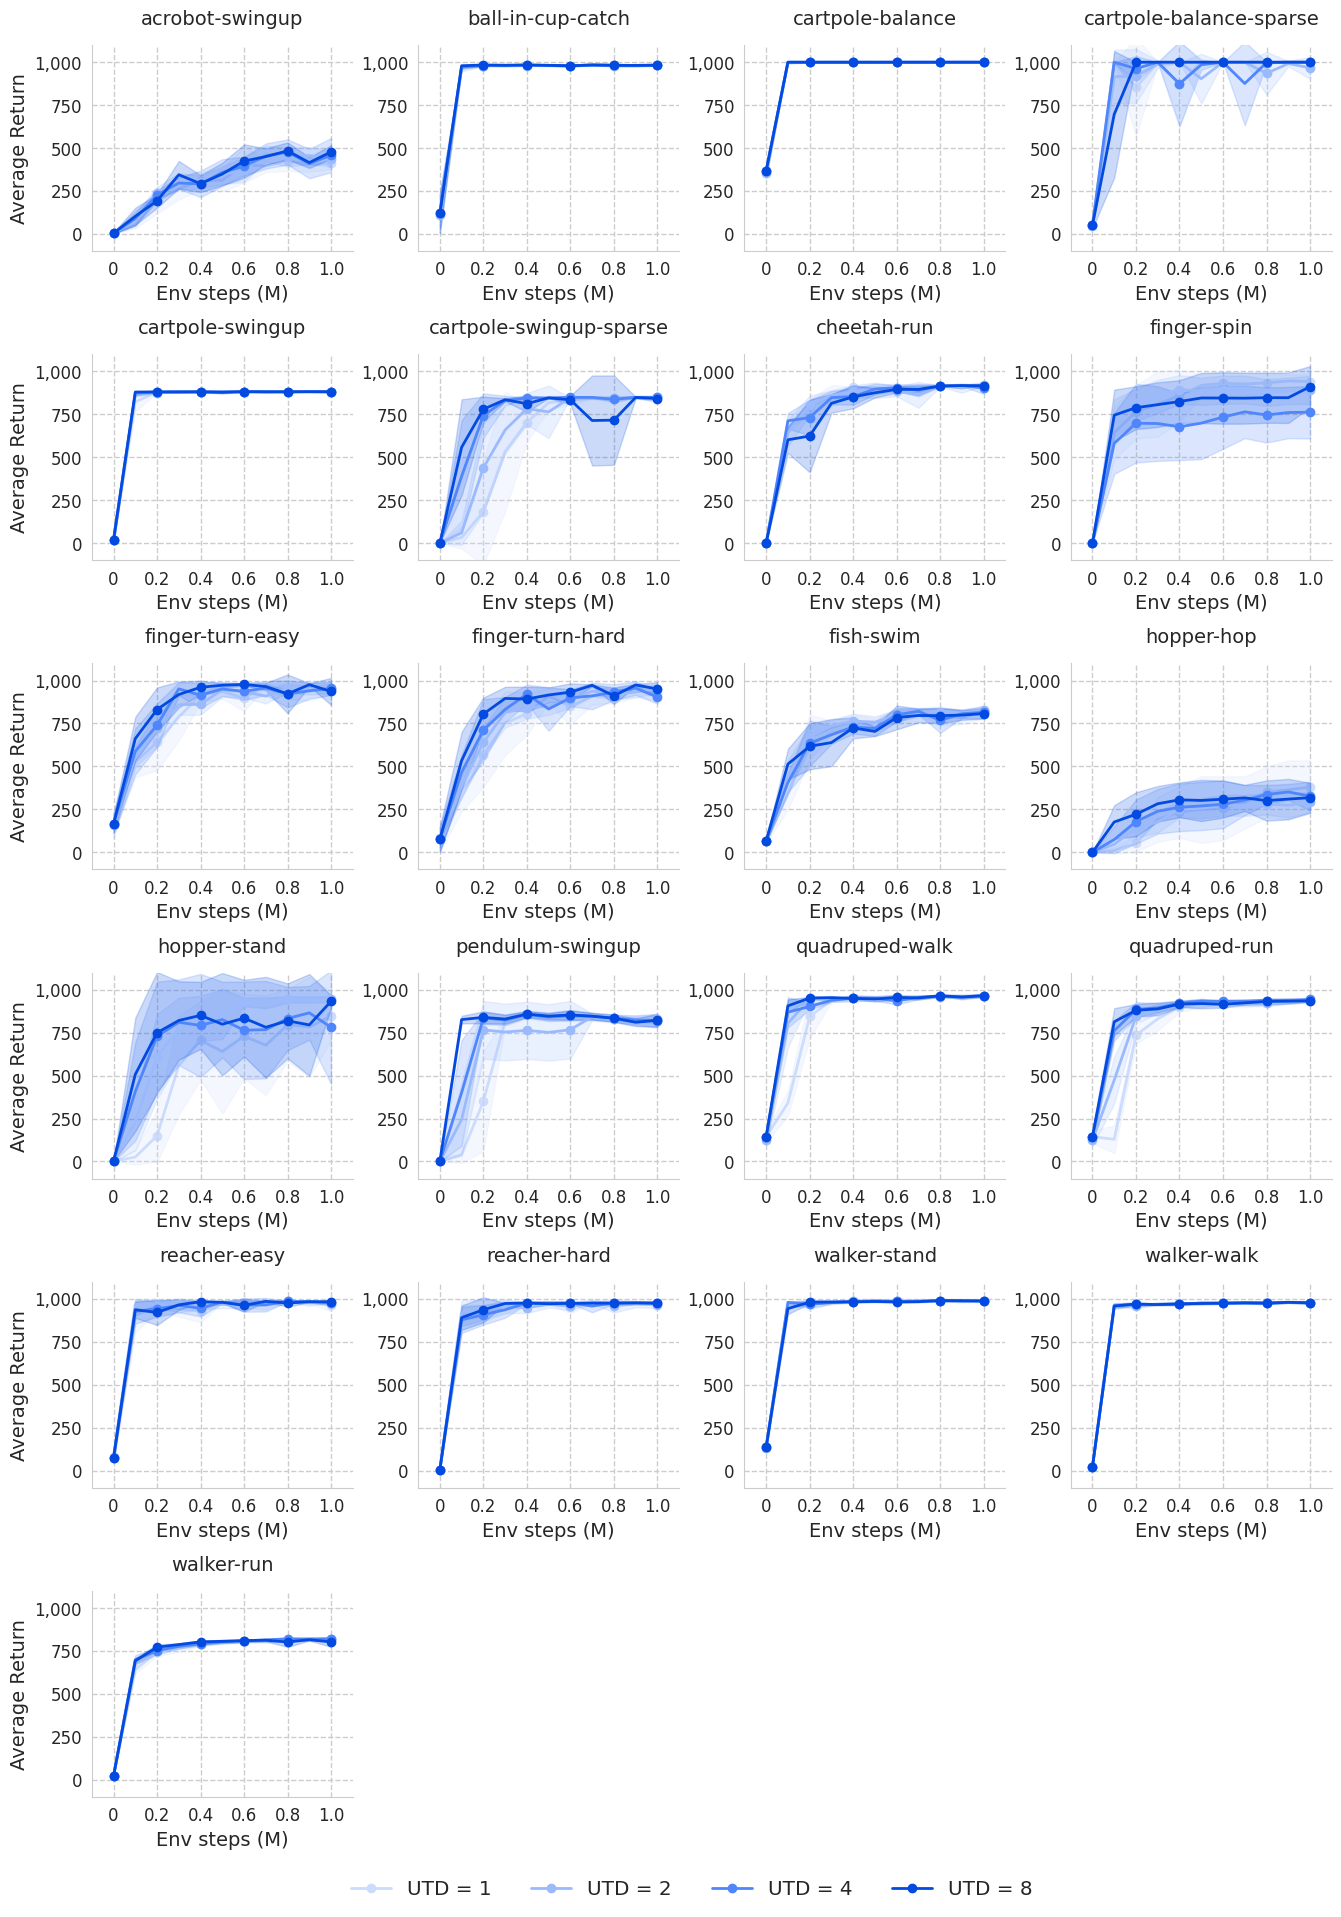

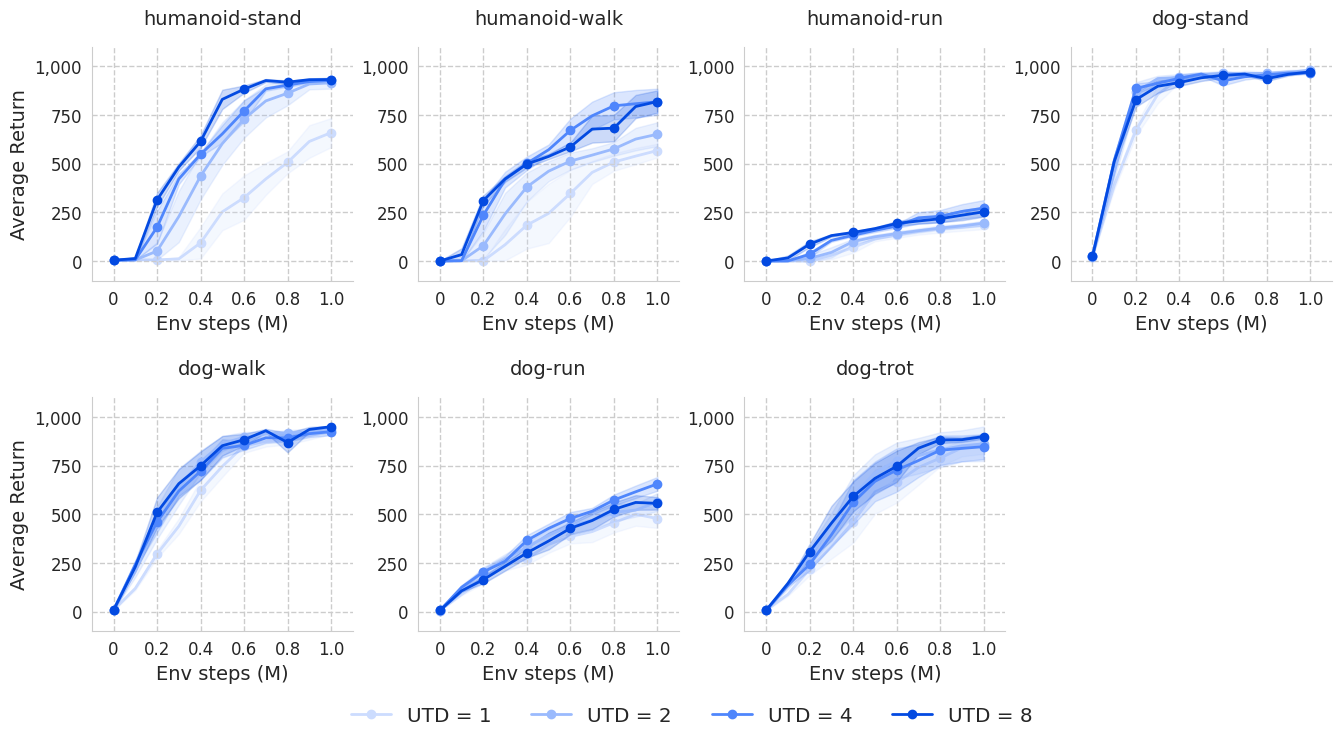

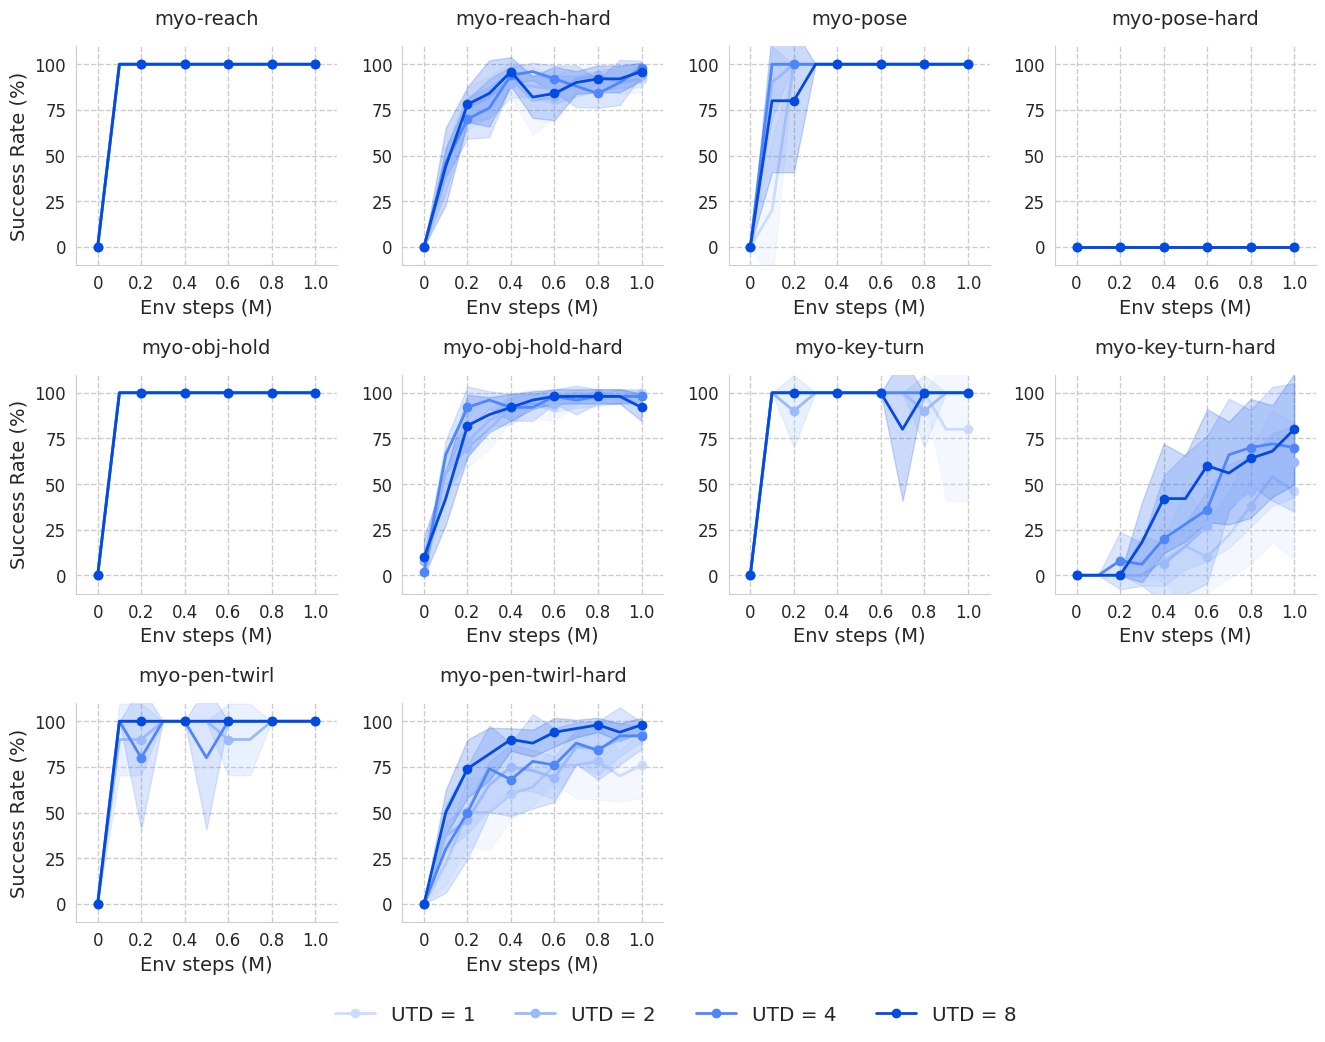

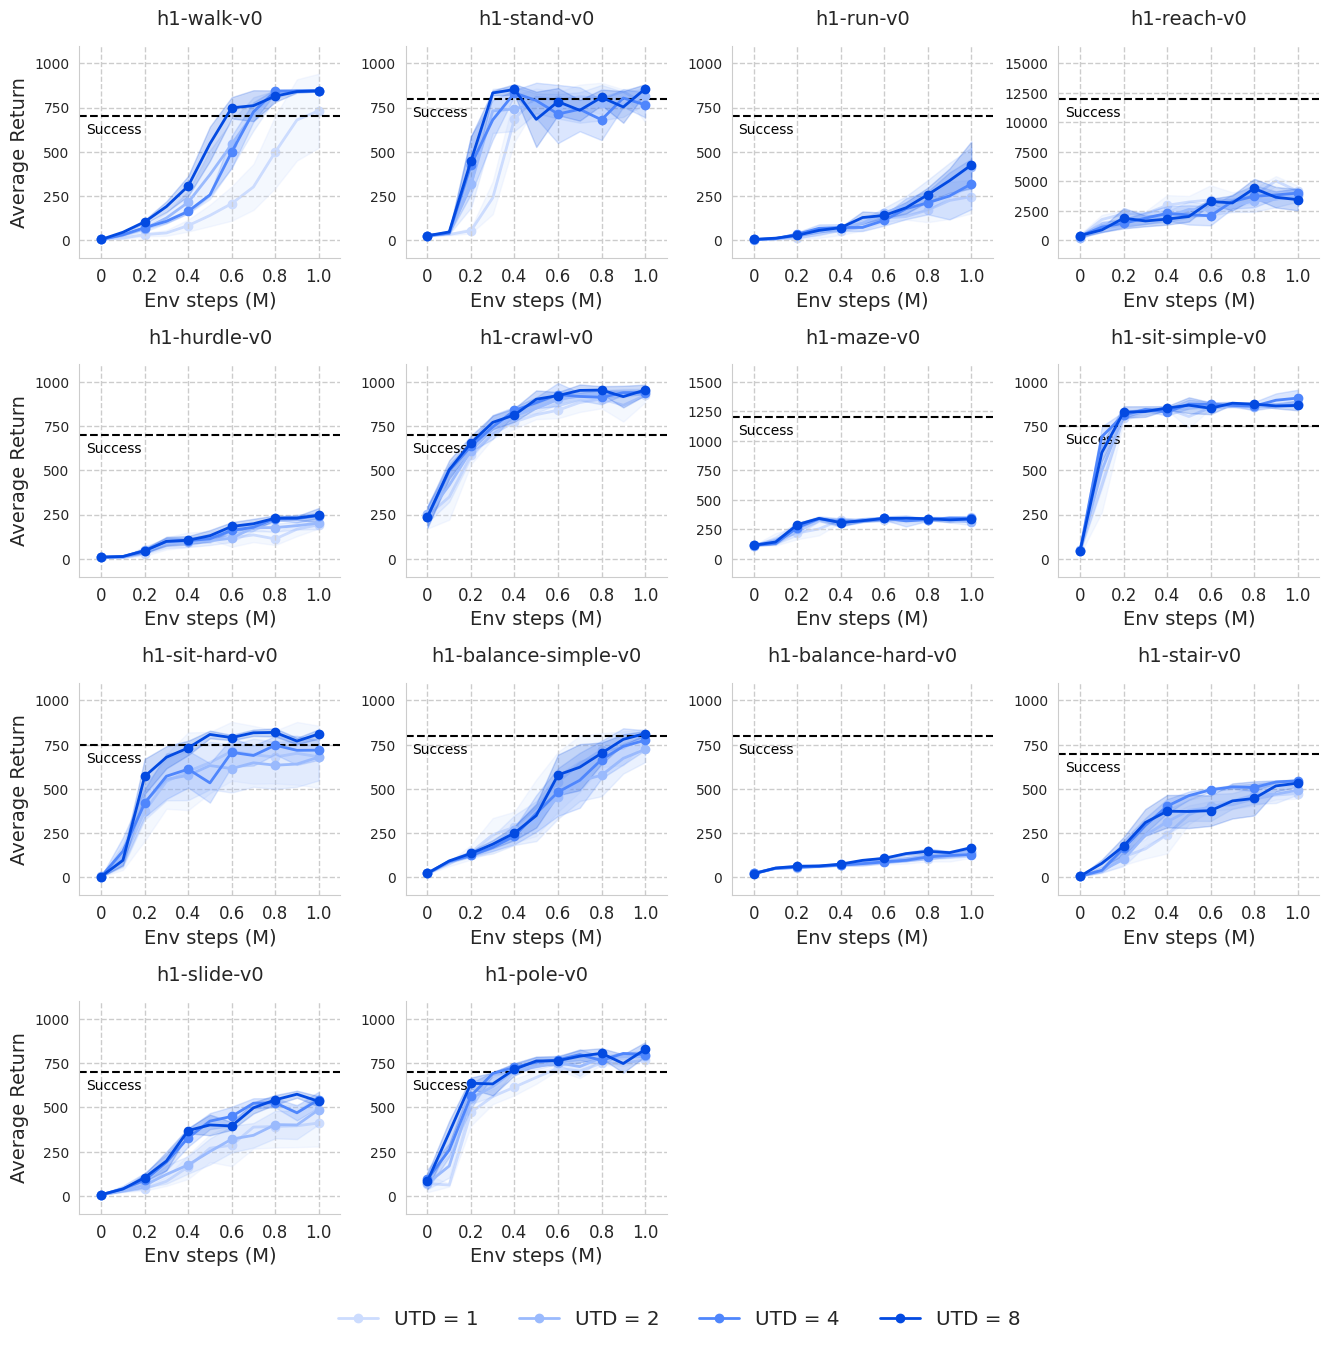

In [53]:
mujoco_eval_df = eval_df[eval_df['env_name'].isin(MUJOCO_ALL)]
dmc_easy_medium_eval_df = eval_df[eval_df['env_name'].isin(DMC_EASY_MEDIUM)]
dmc_hard_eval_df = eval_df[eval_df['env_name'].isin(DMC_HARD)]
myo_eval_df = eval_df[eval_df['env_name'].isin(MYOSUITE_TASKS)]
hb_eval_df = eval_df[eval_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]

plot_environment_metrics_per_env(
    env_dfs=[mujoco_eval_df, dmc_easy_medium_eval_df, dmc_hard_eval_df, myo_eval_df, hb_eval_df],
    env_names=["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard", "MyoSuite", "HumanoidBench"],
    env_dicts=[MUJOCO_ALL, DMC_EASY_MEDIUM, DMC_HARD, MYOSUITE_TASKS, HB_LOCOMOTION_NOHAND],
    metrics=["avg_return", "avg_return", "avg_return", "avg_success", "avg_return"],
    colors=colors,
    x_lim_mins=[0, 0, 0, 0, 0],
    x_lim_maxs=[1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6],
    y_lim_mins=[mujoco_y_info, 0, 0, 0, 0],
    y_lim_maxs=[mujoco_y_info, 1000, 1000, 100, hb_y_lim_max_info],
    y_labels=["Average Return (1K)", "Average Return", "Average Return", "Success Rate (%)", "Average Return"],
    line_width=2.0,
    num_plots_per_row=4,
    plot_widths=[16.0, 16.0, 16.0, 16.0, 16.0],
    plot_heights=[8.0, 24.0, 8.0, 12.0, 16.0],
    plot_hspaces=[0.5, 0.5, 0.5, 0.5, 0.5],
    plot_wspaces=[0.25, 0.25, 0.25, 0.25, 0.25],
    legend_bbox_to_anchors=[(0.5, 0.01), (0.5, 0.10), (0.5, 0.01), (0.5, 0.05), (0.5, 0.06666666)]
)